<a href="https://colab.research.google.com/github/Divyaa2601/Predictive-Student-Success-Monitoring-System/blob/main/notebooks/01_generate_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

N_STUDENTS = 2000

print("Number of students:", N_STUDENTS)

Number of students: 2000


In [ ]:
student_profile = np.random.choice(
    ["strong", "average", "struggling", "disengaged"],
    size=N_STUDENTS,
    p=[0.25, 0.45, 0.20, 0.10]
)

academic_ability = np.zeros(N_STUDENTS)
engagement = np.zeros(N_STUDENTS)
consistency = np.zeros(N_STUDENTS)

for i, profile in enumerate(student_profile):

    if profile == "strong":
        academic_ability[i] = np.random.normal(0.82, 0.10)
        engagement[i] = np.random.normal(0.78, 0.12)
        consistency[i] = np.random.normal(0.80, 0.10)

    elif profile == "average":
        academic_ability[i] = np.random.normal(0.60, 0.14)
        engagement[i] = np.random.normal(0.62, 0.16)
        consistency[i] = np.random.normal(0.62, 0.15)

    elif profile == "struggling":
        academic_ability[i] = np.random.normal(0.32, 0.13)
        engagement[i] = np.random.normal(0.45, 0.18)
        consistency[i] = np.random.normal(0.42, 0.17)

    elif profile == "disengaged":
        academic_ability[i] = np.random.normal(0.58, 0.15)
        engagement[i] = np.random.normal(0.22, 0.12)
        consistency[i] = np.random.normal(0.35, 0.15)

academic_ability = np.clip(academic_ability, 0, 1)
engagement = np.clip(engagement, 0, 1)
consistency = np.clip(consistency, 0, 1)

print(pd.Series(student_profile).value_counts())

average       878
strong        527
struggling    398
disengaged    197
Name: count, dtype: int64


In [ ]:
student_id = [f"STU{i:04d}" for i in range(1, N_STUDENTS + 1)]

semester = np.random.choice(
    [3, 4, 5, 6],
    size=N_STUDENTS,
    p=[0.25, 0.25, 0.25, 0.25]
)

In [ ]:
previous_gpa = (
    3
    + academic_ability * 5
    + consistency * 2
    + np.random.normal(0, 0.7, N_STUDENTS)
)

previous_gpa = np.clip(previous_gpa, 0, 10)
previous_gpa = np.round(previous_gpa, 2)

In [ ]:
attendance_pct = (
    35
    + engagement * 40
    + consistency * 25
    + np.random.normal(0, 8, N_STUDENTS)
)

attendance_pct = np.clip(attendance_pct, 0, 100)
attendance_pct = np.round(attendance_pct, 1)

In [ ]:
internal_1 = (
    15
    + academic_ability * 55
    + engagement * 15
    + consistency * 10
    + np.random.normal(0, 10, N_STUDENTS)
)

internal_1 = np.clip(internal_1, 0, 100)


internal_2 = (
    internal_1 * 0.35
    + academic_ability * 40
    + engagement * 15
    + consistency * 10
    + np.random.normal(0, 11, N_STUDENTS)
)

internal_2 = np.clip(internal_2, 0, 100)

internal_1 = np.round(internal_1, 1)
internal_2 = np.round(internal_2, 1)

In [ ]:
assignment_avg = (
    15
    + academic_ability * 35
    + engagement * 30
    + consistency * 20
    + np.random.normal(0, 10, N_STUDENTS)
)

assignment_avg = np.clip(assignment_avg, 0, 100)


assignment_completion_pct = (
    25
    + engagement * 40
    + consistency * 35
    + np.random.normal(0, 9, N_STUDENTS)
)

assignment_completion_pct = np.clip(
    assignment_completion_pct,
    0,
    100
)

assignment_avg = np.round(assignment_avg, 1)
assignment_completion_pct = np.round(
    assignment_completion_pct, 1
)

In [ ]:
quiz_avg = (
    10
    + academic_ability * 55
    + engagement * 15
    + consistency * 10
    + np.random.normal(0, 12, N_STUDENTS)
)

quiz_avg = np.clip(quiz_avg, 0, 100)
quiz_avg = np.round(quiz_avg, 1)

In [ ]:
study_hours_weekly = (
    1
    + engagement * 12
    + consistency * 6
    + np.random.normal(0, 3, N_STUDENTS)
)

study_hours_weekly = np.clip(
    study_hours_weekly,
    0,
    35
)

study_hours_weekly = np.round(
    study_hours_weekly,
    1
)

In [ ]:
class_participation = (
    engagement * 7
    + consistency * 2
    + np.random.normal(0, 1.5, N_STUDENTS)
)

class_participation = np.clip(
    class_participation,
    0,
    10
)

class_participation = np.round(
    class_participation,
    1
)

In [ ]:
late_submission_rate = (
    0.65
    - engagement * 0.30
    - consistency * 0.25
    + np.random.normal(0, 0.12, N_STUDENTS)
)

late_submission_rate = np.clip(
    late_submission_rate,
    0.02,
    0.95
)

late_submissions = np.random.binomial(
    n=10,
    p=late_submission_rate
)

In [ ]:
final_score = (
    previous_gpa * 2.0
    + attendance_pct * 0.08
    + internal_1 * 0.15
    + internal_2 * 0.25
    + assignment_avg * 0.08
    + assignment_completion_pct * 0.04
    + quiz_avg * 0.10
    + study_hours_weekly * 0.15
    + class_participation * 0.30
    - late_submissions * 0.40
    + academic_ability * 8
    + np.random.normal(0, 8, N_STUDENTS)
)

final_score = np.clip(final_score, 0, 100)
final_score = np.round(final_score, 1)

In [ ]:
edge_case_type = np.array(["normal"] * N_STUDENTS, dtype=object)

available_indices = np.arange(N_STUDENTS)
np.random.shuffle(available_indices)

case_size = 40

cases = {
    "low_attendance_high_performance": available_indices[0:40],
    "high_attendance_low_performance": available_indices[40:80],
    "sudden_improvement": available_indices[80:120],
    "sudden_decline": available_indices[120:160],
    "assignment_problem": available_indices[160:200],
    "low_engagement_high_performance": available_indices[200:240]
}

In [ ]:
idx = cases["low_attendance_high_performance"]

attendance_pct[idx] = np.random.uniform(40, 60, len(idx))
internal_1[idx] = np.random.uniform(75, 95, len(idx))
internal_2[idx] = np.random.uniform(80, 100, len(idx))
assignment_avg[idx] = np.random.uniform(75, 100, len(idx))

edge_case_type[idx] = "low_attendance_high_performance"


idx = cases["high_attendance_low_performance"]

attendance_pct[idx] = np.random.uniform(90, 100, len(idx))
internal_1[idx] = np.random.uniform(25, 50, len(idx))
internal_2[idx] = np.random.uniform(25, 50, len(idx))
quiz_avg[idx] = np.random.uniform(20, 50, len(idx))

edge_case_type[idx] = "high_attendance_low_performance"


idx = cases["sudden_improvement"]

internal_1[idx] = np.random.uniform(25, 50, len(idx))
internal_2[idx] = np.random.uniform(70, 95, len(idx))
quiz_avg[idx] = np.random.uniform(70, 95, len(idx))

edge_case_type[idx] = "sudden_improvement"


idx = cases["sudden_decline"]

internal_1[idx] = np.random.uniform(75, 95, len(idx))
internal_2[idx] = np.random.uniform(30, 55, len(idx))
assignment_avg[idx] = np.random.uniform(30, 60, len(idx))

edge_case_type[idx] = "sudden_decline"


idx = cases["assignment_problem"]

attendance_pct[idx] = np.random.uniform(75, 95, len(idx))
assignment_avg[idx] = np.random.uniform(20, 50, len(idx))
assignment_completion_pct[idx] = np.random.uniform(30, 60, len(idx))
late_submissions[idx] = np.random.randint(6, 11, len(idx))

edge_case_type[idx] = "assignment_problem"


idx = cases["low_engagement_high_performance"]

study_hours_weekly[idx] = np.random.uniform(0, 4, len(idx))
class_participation[idx] = np.random.uniform(0, 3, len(idx))
internal_1[idx] = np.random.uniform(75, 95, len(idx))
internal_2[idx] = np.random.uniform(75, 100, len(idx))
quiz_avg[idx] = np.random.uniform(75, 100, len(idx))

edge_case_type[idx] = "low_engagement_high_performance"

In [ ]:
idx = cases["low_attendance_high_performance"]
final_score[idx] = np.clip(
    np.random.normal(82, 7, len(idx)), 60, 100
)

idx = cases["high_attendance_low_performance"]
final_score[idx] = np.clip(
    np.random.normal(42, 8, len(idx)), 15, 60
)

idx = cases["sudden_improvement"]
final_score[idx] = np.clip(
    np.random.normal(72, 8, len(idx)), 50, 95
)

idx = cases["sudden_decline"]
final_score[idx] = np.clip(
    np.random.normal(48, 9, len(idx)), 20, 70
)

idx = cases["assignment_problem"]
final_score[idx] = np.clip(
    np.random.normal(52, 9, len(idx)), 25, 75
)

idx = cases["low_engagement_high_performance"]
final_score[idx] = np.clip(
    np.random.normal(80, 7, len(idx)), 60, 100
)

final_score = np.round(final_score, 1)

In [ ]:
risk_level = np.where(
    final_score < 45,
    "High",
    np.where(
        final_score < 60,
        "Medium",
        "Low"
    )
)

In [ ]:
df = pd.DataFrame({
    "student_id": student_id,
    "semester": semester,
    "previous_gpa": previous_gpa,
    "attendance_pct": attendance_pct,
    "internal_1": internal_1,
    "internal_2": internal_2,
    "assignment_avg": assignment_avg,
    "assignment_completion_pct": assignment_completion_pct,
    "quiz_avg": quiz_avg,
    "study_hours_weekly": study_hours_weekly,
    "class_participation": class_participation,
    "late_submissions": late_submissions,
    "final_score": final_score,
    "risk_level": risk_level,
    "edge_case_type": edge_case_type
})

df.head(10)

,student_id,semester,previous_gpa,attendance_pct,internal_1,internal_2,assignment_avg,assignment_completion_pct,quiz_avg,study_hours_weekly,class_participation,late_submissions,final_score,risk_level,edge_case_type
0,STU0001,4,6.13,64.9,60.500000,56.800000,62.3,66.0,51.300000,10.400000,6.100000,1,41.5,High,normal
1,STU0002,4,7.19,52.5,55.700000,66.400000,68.5,67.7,45.200000,5.100000,2.700000,6,58.9,Medium,normal
2,STU0003,5,6.40,52.1,53.800000,55.900000,63.4,65.4,32.300000,12.000000,2.300000,0,48.4,Medium,normal
3,STU0004,6,6.86,74.9,64.100000,42.200000,77.8,52.2,52.700000,10.500000,4.800000,5,54.5,Medium,normal
4,STU0005,4,9.26,74.4,82.300000,64.900000,78.2,72.3,71.100000,9.900000,9.300000,4,70.7,Low,normal
5,STU0006,6,8.58,88.1,79.400000,82.500000,95.0,99.2,77.000000,16.400000,4.100000,6,71.4,Low,normal
6,STU0007,4,8.86,90.4,75.241837,79.273181,74.0,88.8,86.331065,0.493401,0.571977,2,91.4,Low,low_engagement_high_performance
7,STU0008,3,3.35,73.9,39.400000,20.900000,47.9,66.2,18.600000,5.200000,4.600000,5,27.9,High,normal
8,STU0009,3,5.72,74.4,56.300000,37.900000,69.8,75.8,48.900000,13.900000,8.100000,0,67.6,Low,normal
9,STU0010,3,4.97,72.6,49.300000,41.000000,44.3,68.4,13.500000,13.600000,2.900000,2,43.1,High,normal


In [ ]:
missing_columns = [
    "quiz_avg",
    "study_hours_weekly",
    "class_participation"
]

for column in missing_columns:
    missing_indices = np.random.choice(
        df.index,
        size=int(0.03 * N_STUDENTS),
        replace=False
    )

    df.loc[missing_indices, column] = np.nan

In [ ]:
print("Dataset shape:", df.shape)

print("\nRisk distribution:")
print(df["risk_level"].value_counts())

print("\nRisk percentage:")
print(
    df["risk_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nEdge cases:")
print(df["edge_case_type"].value_counts())

Dataset shape: (2000, 15)

Risk distribution:
risk_level
Low       1199
Medium     500
High       301
Name: count, dtype: int64

Risk percentage:
risk_level
Low       59.95
Medium    25.00
High      15.05
Name: proportion, dtype: float64

Missing values:
student_id                    0
semester                      0
previous_gpa                  0
attendance_pct                0
internal_1                    0
internal_2                    0
assignment_avg                0
assignment_completion_pct     0
quiz_avg                     60
study_hours_weekly           60
class_participation          60
late_submissions              0
final_score                   0
risk_level                    0
edge_case_type                0
dtype: int64

Duplicate rows:
0

Edge cases:
edge_case_type
normal                             1760
low_engagement_high_performance      40
low_attendance_high_performance      40
sudden_decline                       40
assignment_problem                   40
sudde

In [ ]:
print(df["final_score"].describe())

print("\nScore ranges:")

print("Below 40:", (df["final_score"] < 40).sum())
print("Below 45:", (df["final_score"] < 45).sum())
print("Below 50:", (df["final_score"] < 50).sum())
print("Below 55:", (df["final_score"] < 55).sum())
print("Below 60:", (df["final_score"] < 60).sum())

count    2000.000000
mean       64.676150
std        17.989073
min         9.300000
25%        51.600000
50%        65.150000
75%        78.300000
max       100.000000
Name: final_score, dtype: float64

Score ranges:
Below 40: 191
Below 45: 301
Below 50: 439
Below 55: 621
Below 60: 801


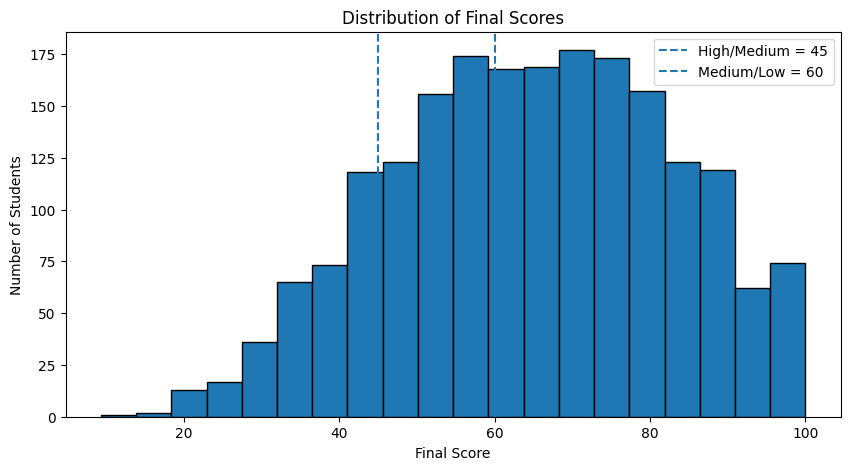

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["final_score"],
    bins=20,
    edgecolor="black"
)

plt.axvline(45, linestyle="--", label="High/Medium = 45")
plt.axvline(60, linestyle="--", label="Medium/Low = 60")

plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Scores")
plt.legend()

plt.show()

In [ ]:
df.describe()

,semester,previous_gpa,attendance_pct,internal_1,internal_2,assignment_avg,assignment_completion_pct,quiz_avg,study_hours_weekly,class_participation,late_submissions,final_score
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1940.000000,1940.000000,1940.000000,2000.000000,2000.000000
mean,4.51850,7.137575,73.561494,63.290233,61.422528,65.022573,68.871168,58.021451,11.454991,5.293038,3.325500,64.676150
std,1.11637,1.487937,14.918787,18.427006,20.565345,18.239994,16.681705,19.382851,4.540623,2.299219,2.192248,17.989073
min,3.00000,2.590000,26.100000,0.000000,0.000000,14.600000,17.400000,0.000000,0.000000,0.000000,0.000000,9.300000
25%,4.00000,6.120000,63.400000,50.075000,45.900000,51.775000,57.500000,45.000000,8.300000,3.800000,2.000000,51.600000
50%,5.00000,7.180000,74.600000,63.700000,61.950000,65.700000,70.050000,57.800000,11.800000,5.400000,3.000000,65.150000
75%,6.00000,8.240000,84.700000,77.500000,77.625000,78.200000,81.300000,72.100000,14.800000,6.900000,5.000000,78.300000
max,6.00000,10.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,24.400000,10.000000,10.000000,100.000000


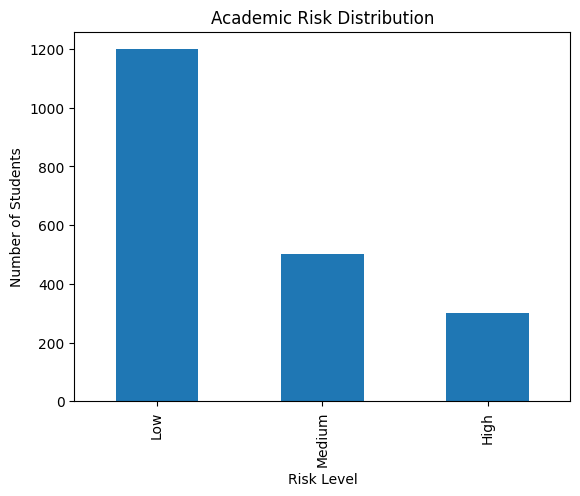

In [ ]:
df["risk_level"].value_counts().plot(
    kind="bar",
    title="Academic Risk Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
df.to_csv(
    "student_success_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
check_df = pd.read_csv("student_success_dataset.csv")

print(check_df.shape)
print(check_df["risk_level"].value_counts())
check_df.head()

(2000, 15)
risk_level
Low       1199
Medium     500
High       301
Name: count, dtype: int64


,student_id,semester,previous_gpa,attendance_pct,internal_1,internal_2,assignment_avg,assignment_completion_pct,quiz_avg,study_hours_weekly,class_participation,late_submissions,final_score,risk_level,edge_case_type
0,STU0001,4,6.13,64.9,60.5,56.8,62.3,66.0,51.3,10.4,6.1,1,41.5,High,normal
1,STU0002,4,7.19,52.5,55.7,66.4,68.5,67.7,45.2,5.1,2.7,6,58.9,Medium,normal
2,STU0003,5,6.40,52.1,53.8,55.9,63.4,65.4,32.3,12.0,2.3,0,48.4,Medium,normal
3,STU0004,6,6.86,74.9,64.1,42.2,77.8,52.2,52.7,10.5,4.8,5,54.5,Medium,normal
4,STU0005,4,9.26,74.4,82.3,64.9,78.2,72.3,71.1,9.9,9.3,4,70.7,Low,normal
